<a href="https://colab.research.google.com/github/Corius77/diffusion_models_notes/blob/main/diffusion_lost_functions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Some experiments with loss functions used sampling

## Setup and imports

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
import torchvision
from datasets import load_dataset
from diffusers import DDIMScheduler, DDPMPipeline
from matplotlib import pyplot as plt
from PIL import Image
from torchvision import transforms
from tqdm.auto import tqdm

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
device = (
    "mps"
    if torch.backends.mps.is_available()
    else "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

## Color loss

In [ ]:
def color_loss(images, target_color=(0.1, 0.9, 0.5)):
    """Given a target color (R, G, B) return a loss for how far away on average
    the images' pixels are from that color. Defaults to a light teal: (0.1, 0.9, 0.5)"""
    target = (
        torch.tensor(target_color).to(images.device) * 2 - 1
    )  # Map target color to (-1, 1)
    target = target[
        None, :, None, None
    ]  # Get shape right to work with the images (b, c, h, w)
    error = torch.abs(
        images - target
    ).mean()  # Mean absolute difference between the image pixels and the target color
    return error

In [ ]:
shape = (3, 256, 256)

In [ ]:
x = torch.randn(shape).to(device)

In [ ]:
def tensor_to_img(x):
  grid = torchvision.utils.make_grid(x, nrow=4)
  im = grid.permute(1, 2, 0).cpu().clip(-1, 1) * 0.5 + 0.5
  return Image.fromarray(np.array(im * 255).astype(np.uint8))

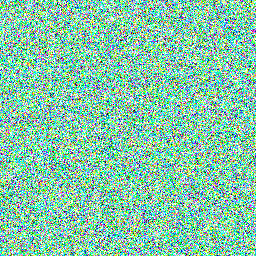

In [ ]:
tensor_to_img(x)

In [ ]:
color_loss(x)

tensor(0.9333, device='cuda:0')

In [ ]:
y = torch.zeros(shape)

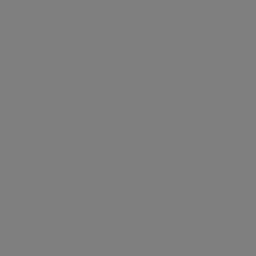

In [ ]:
tensor_to_img(y)

In [ ]:
color_loss(y)

tensor(0.5333)

In [ ]:
def color_tensor(x, target_color=(0.1, 0.9, 0.5)):
  for i in range(0, 3):
    x[i] += target_color[i]

In [ ]:
color_tensor(y)

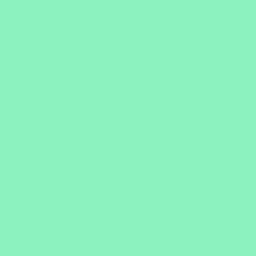

In [ ]:
tensor_to_img(y)

In [ ]:
color_loss(y)

tensor(0.5000)

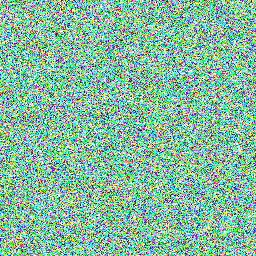

In [ ]:
make_image(x)

In [ ]:
color_tensor(x)

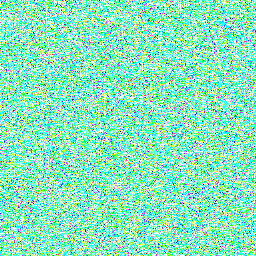

In [ ]:
make_image(x)

In [ ]:
color_loss(x)

tensor(1.1672, device='cuda:0')

## Load the pretrained pipeline


In [ ]:
pipeline_name = "google/ddpm-church-256"
image_pipe = DDPMPipeline.from_pretrained(pipeline_name).to(device)

model_index.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-church-256/snapshots/5a1118b5a35e744d59a4215a8c72a4d7619b9e04: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-church-256/snapshots/5a1118b5a35e744d59a4215a8c72a4d7619b9e04.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


In [ ]:
scheduler = DDIMScheduler.from_pretrained(pipeline_name)
scheduler.set_timesteps(num_inference_steps=40)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


In [ ]:
from IPython.display import display, clear_output

In [ ]:
def minimal_sampling(x):
  for i, t in tqdm(enumerate(scheduler.timesteps)):
    model_input = scheduler.scale_model_input(x, t)
    with torch.no_grad():
      noise_pred = image_pipe.unet(model_input, t)['sample']
      x = scheduler.step(noise_pred, t, x).prev_sample

      clear_output(wait=True)
      display(tensor_to_img(x))
  return x

In [158]:
def get_rand_tensor(shape=(8, 3, 256, 256)):
  return torch.randn(shape).to(device)

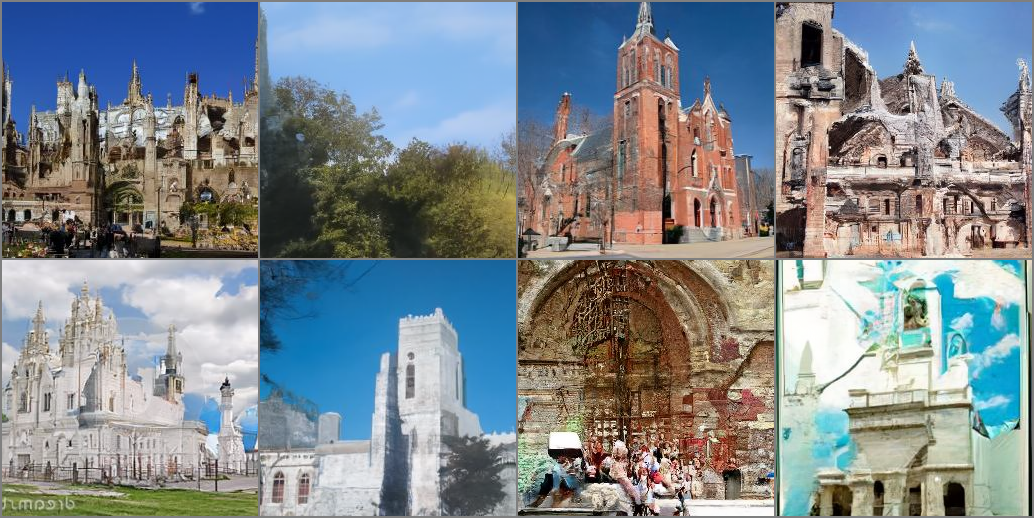

In [159]:
x = get_rand_tensor()
x = minimal_sampling(x)

In [155]:
def color_sampling(x, target_color=(43, 13, 35), guidance_loss_scale=20, color_loss=color_loss):
  target_color = tuple([i/255 for i in target_color])

  for i, t in tqdm(enumerate(scheduler.timesteps)):
    model_input = scheduler.scale_model_input(x, t)

    with torch.no_grad():
      noise_pred = image_pipe.unet(model_input, t)['sample']

    x = x.detach().requires_grad_()

    x0 = scheduler.step(noise_pred, t, x).pred_original_sample

    loss = color_loss(x0, target_color) * guidance_loss_scale
    if i % 10 == 0:
      print(i, 'loss:', loss.item())

    cond_grad = -torch.autograd.grad(loss, x)[0]

    x = x.detach() + cond_grad

    x = scheduler.step(noise_pred, t, x).prev_sample

    clear_output(wait=True)
    display(tensor_to_img(x))
  return x

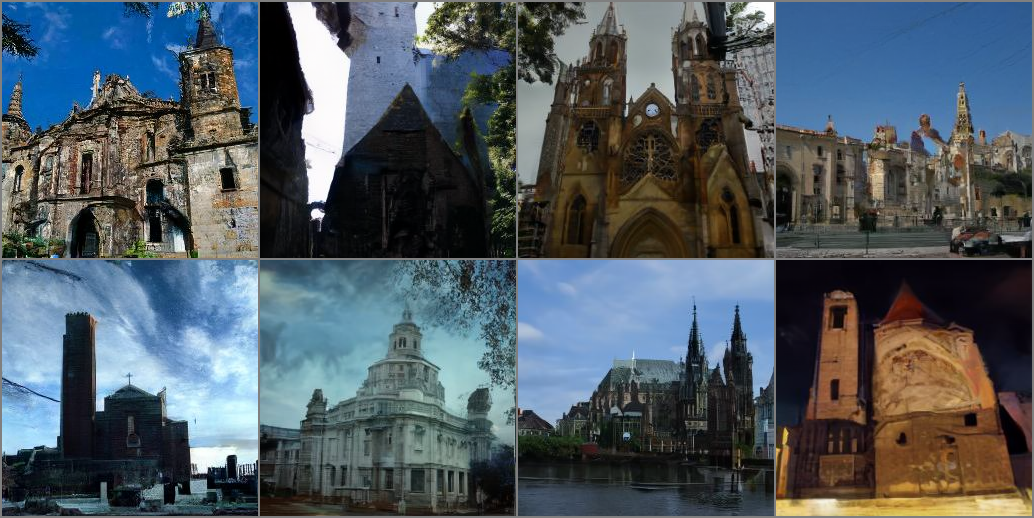

In [160]:
x = get_rand_tensor()
x = color_sampling(x)

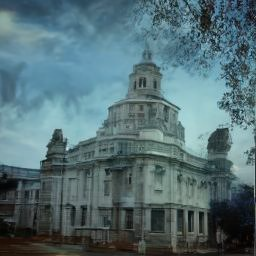

In [163]:
tensor_to_img(x[5])

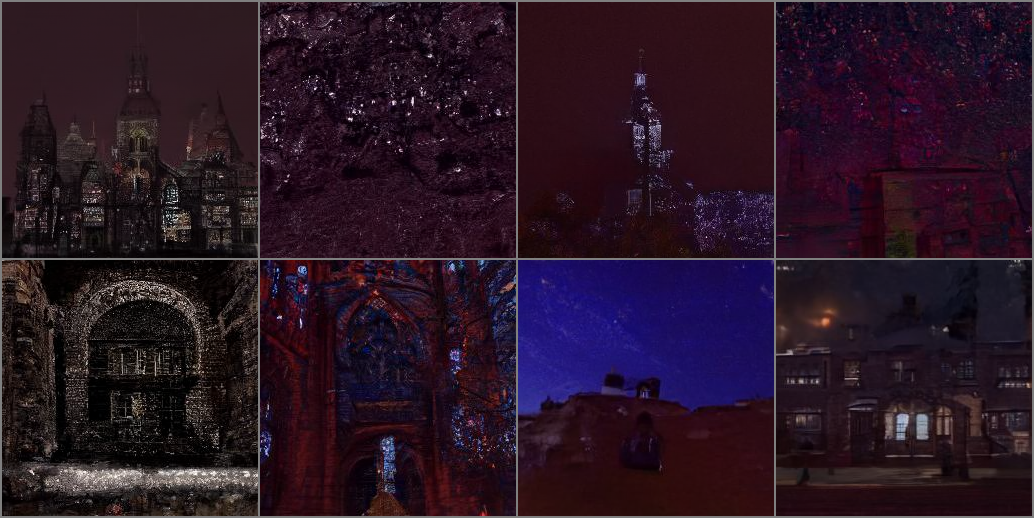

In [164]:
x = get_rand_tensor()
x = color_sampling(x=x, guidance_loss_scale=50)

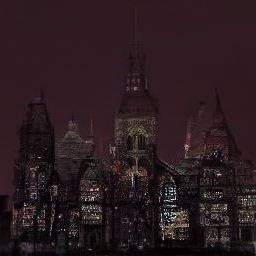

In [165]:
tensor_to_img(x[0])

In [166]:
target_color=(43, 13, 35)
target_color = tuple([i/255 for i in target_color])
color_loss(x[0], target_color)

tensor(0.1007, device='cuda:0')